Stress level predictor

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

Loading data

In [82]:
data=pd.read_csv("Gaming_Academic_Performance.csv")
df=pd.DataFrame(data)
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


Cleaning data

In [83]:
df=df.dropna()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

Label encoding

In [84]:
encoder= LabelEncoder()
df['gender']=encoder.fit_transform(df['gender'])
df['gaming_genre']=encoder.fit_transform(df['gaming_genre'])
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,1,7.23,8.78,6.96,91.44,1,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,1,0.07,8.72,7.63,63.63,0,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,0,1.73,9.56,4.40,83.26,0,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,0,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,0,5.36,5.83,5.55,65.57,1,1.01,8.23,249.31,12.48,Low,58.710000


One-hot encoding

In [85]:
# df=pd.get_dummies(df,columns=['stress_level'])
# df.head()

Spliting X and y

In [86]:
X=df.drop(['student_id','grades','addiction_score','stress_level'],axis=1)
y=df['stress_level']

Train test spliting

In [87]:
XTrain,XTest,yTrain,yTest=train_test_split(X,y,random_state=42,test_size=0.3)

Random forest classifier

In [88]:
model=RandomForestClassifier(random_state=42,n_estimators=100)
model.fit(XTrain,yTrain)
prediction=model.predict(XTest)

Evaluation of model

In [89]:
print("Accuracy:", accuracy_score(yTest, prediction))

Accuracy: 1.0


Actual vs Predicted heatmap

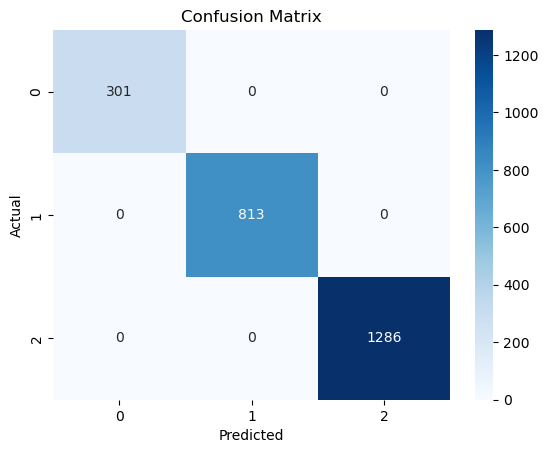

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(yTest, prediction)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Actual vs Predicted plot

   Actual Predicted
0  Medium    Medium
1  Medium    Medium
2  Medium    Medium
3     Low       Low
4    High      High


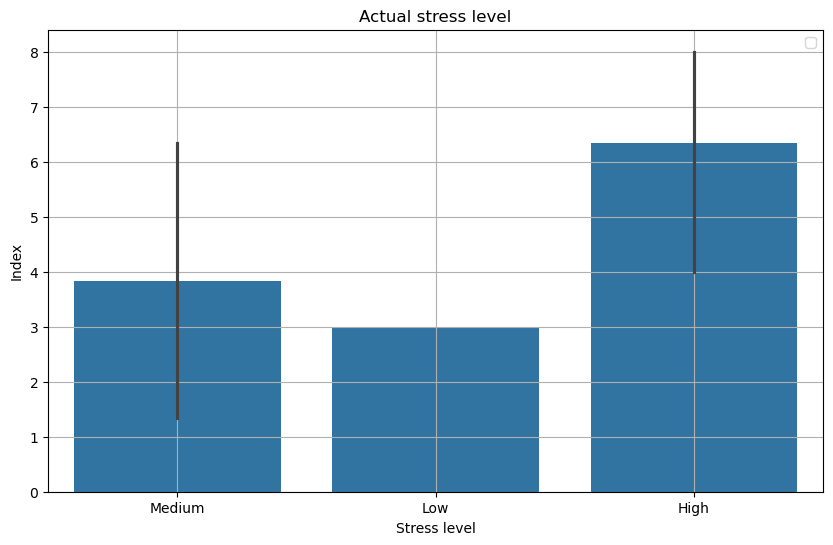

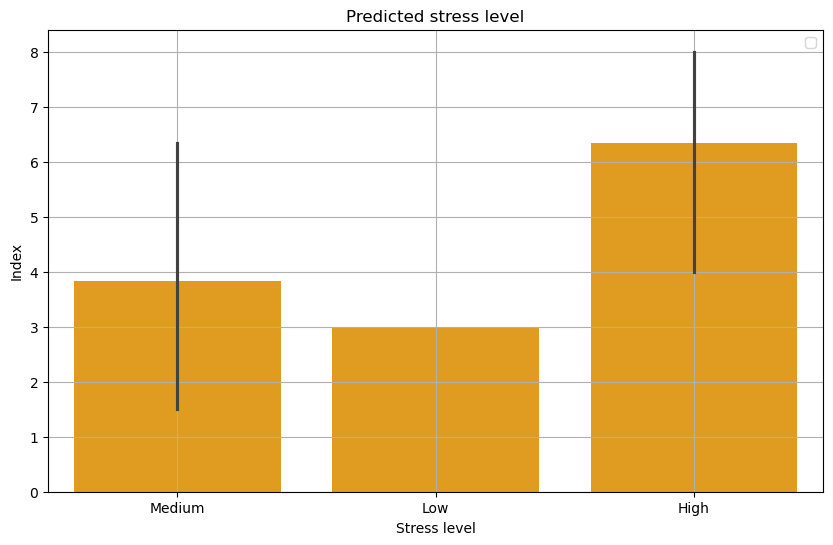

In [91]:
result=pd.DataFrame({
    "Actual": yTest.values,
    'Predicted': prediction
})

print(result.head())
result=result.head(10)


plt.figure(figsize=(10,6))
sns.barplot(data=result,y=result.index,x='Actual')
plt.title("Actual stress level")
plt.xlabel("Stress level")
plt.ylabel("Index")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=result,y=result.index,x="Predicted",color="orange")
plt.title("Predicted stress level")
plt.xlabel("Stress level")
plt.ylabel("Index")
plt.legend()
plt.grid(True)
plt.show()

Inputs

In [92]:
try:
    age = int(input("Enter age: "))
    gender = input("Enter gender (Male/Female): ")
    gamingHours = float(input("Enter gaming hours: "))
    studyHours = float(input("Enter study hours: "))
    sleepHours = float(input("Enter sleep hours: "))
    attendance = float(input("Enter attendance: "))
    gamingGenre = input("Enter gaming genre: ")
    socialActivity = float(input("Enter social activity: "))
    deviceUsage = float(input("Enter device usage: "))
    reactionTime = float(input("Enter reaction time(ms): "))

    gender=1 if gender.lower()== "male" else 0
    if gamingGenre.lower()=="fps":
        gamingGenre=0
    elif gamingGenre.lower()== 'casual':
        gamingGenre=1
    else:
        gamingGenre=2

    userInput=pd.DataFrame([[age,gender,gamingHours,studyHours,sleepHours,attendance,gamingGenre,socialActivity,deviceUsage,reactionTime]],columns=X.columns)
    result=model.predict(userInput)

    print(f"Predicted Stress Level: {result[0]}")
except Exception as e:
    print("An error occuried",e)


Predicted Stress Level: Low
